In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Loading and Preprocessing ---
print("--- Loading and Preprocessing Data ---")

# Load the datasets
try:
    df_feb = pd.read_csv('index_1.csv')
    df_mar = pd.read_csv('index_2.csv')
except FileNotFoundError:
    print("Error: Make sure 'index_1.csv' and 'index_2.csv' are in the same directory as this notebook.")
    # Stop execution if files aren't found
    raise

# Rename columns in df_mar to match df_feb for concatenation
# NOTE: df_mar is missing the 'card' column in the shared content. We will ignore it for merges/card-based analysis on df_mar only.
df_mar = df_mar.rename(columns={'datetime': 'datetime', 'money': 'money', 'cash_type': 'cash_type', 'coffee_name': 'coffee_name'})
df_mar['card'] = None # Add missing 'card' column for consistency, setting to None

# Ensure datetime columns are in correct format and extract 'hour'
df_feb['datetime'] = pd.to_datetime(df_feb['datetime'])
df_mar['datetime'] = pd.to_datetime(df_mar['datetime'])

df_feb['month'] = 'February'
df_mar['month'] = 'March'

# Combine datasets (Q4: Cross-Month Comparison foundation)
df_combined = pd.concat([df_feb, df_mar], ignore_index=True)
df_combined['hour'] = df_combined['datetime'].dt.hour
df_combined['date_only'] = df_combined['datetime'].dt.date

print(f"Index 1 (Feb) records: {len(df_feb)}")
print(f"Index 2 (Mar) records: {len(df_mar)}")
print(f"Combined records: {len(df_combined)}\n")


# -------------------------------------------------------------
## 1. Customer Behavior & 2. Sales Analysis (Insights)
# -------------------------------------------------------------

print("## Customer & Sales Insights (Combined Data)")
print("---")

# 1. Which coffees are most popular? (By transaction count)
popular_coffees = df_combined['coffee_name'].value_counts().nlargest(5)
print("1a. Most Popular Coffees (Top 5 by Count):\n", popular_coffees)














--- Loading and Preprocessing Data ---
Index 1 (Feb) records: 3636
Index 2 (Mar) records: 262
Combined records: 3898

## Customer & Sales Insights (Combined Data)
---
1a. Most Popular Coffees (Top 5 by Count):
 coffee_name
Americano with Milk    824
Latte                  806
Americano              593
Cappuccino             517
Cortado                292
Name: count, dtype: int64



1b. Payment Method Preference (Total Transactions):
 cash_type
card    3729
cash     169
Name: count, dtype: int64


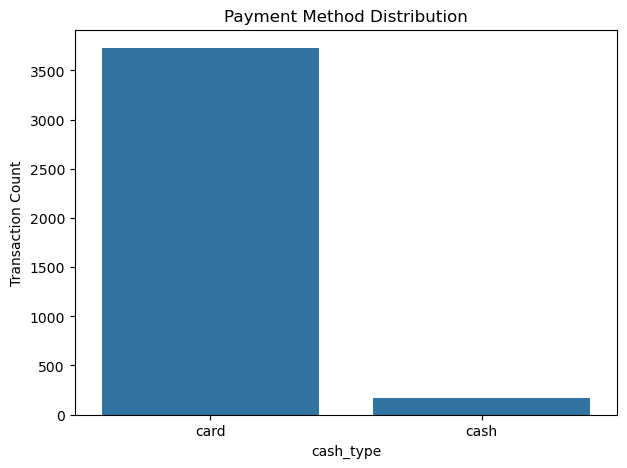

In [3]:
# 2. Do people prefer card, cash, or UPI?
payment_preference = df_combined['cash_type'].value_counts()
print("\n1b. Payment Method Preference (Total Transactions):\n", payment_preference)
# Visualization for payment preference
plt.figure(figsize=(7, 5))
sns.barplot(x=payment_preference.index, y=payment_preference.values)
plt.title('Payment Method Distribution')
plt.ylabel('Transaction Count')
plt.show()

In [4]:
# 3. At what time of the day are people most likely to buy coffee? (Peak Hours - Operational Insight)
transactions_by_hour = df_combined['hour'].value_counts().sort_index()
print("\n3/Op. Insight 1. Transactions by Hour of Day:\n", transactions_by_hour)
# Find actual peak hour(s)
peak_hours = transactions_by_hour[transactions_by_hour == transactions_by_hour.max()].index.tolist()
print(f"   The absolute peak hour(s) (by count) are: {peak_hours}")


3/Op. Insight 1. Transactions by Hour of Day:
 hour
6       5
7      99
8     246
9     258
10    363
11    316
12    271
13    241
14    245
15    267
16    307
17    267
18    247
19    253
20    177
21    210
22    123
23      3
Name: count, dtype: int64
   The absolute peak hour(s) (by count) are: [10]


In [5]:
# 4. Which coffee earns the most revenue?
revenue_by_coffee = df_combined.groupby('coffee_name')['money'].sum().nlargest(5)
print("\n2a. Coffees Earning Most Revenue (Top 5 by Money):\n", revenue_by_coffee)


2a. Coffees Earning Most Revenue (Top 5 by Money):
 coffee_name
Latte                  28658.30
Americano with Milk    25269.12
Cappuccino             18514.14
Americano              15437.26
Hot Chocolate          10172.46
Name: money, dtype: float64


In [6]:
# 5. What is the average ticket size for different coffees?
avg_ticket_size = df_combined.groupby('coffee_name')['money'].mean().sort_values(ascending=False).round(2)
print("\n2b. Average Ticket Size per Coffee:\n", avg_ticket_size)


2b. Average Ticket Size per Coffee:
 coffee_name
Hot Chocolate                 36.07
Cappuccino                    35.81
Cocoa                         35.71
Latte                         35.56
Double espresso with milk     32.00
Americano with Milk           30.67
Chocolate with coffee         30.00
Hot milkshake                 30.00
Mochaccino                    30.00
Coffee with Irish whiskey     29.00
Coffee with chocolate         28.00
Double Irish whiskey          28.00
Vanilla with Irish whiskey    28.00
Super chocolate               28.00
Caramel with chocolate        28.00
Caramel coffee                28.00
Caramel with Irish whiskey    28.00
Irish whiskey with milk       27.00
Chocolate with milk           27.00
Irish with chocolate          27.00
Vanilla coffee                27.00
Double ristretto              27.00
Double espresso               27.00
Americano                     26.03
Cortado                       25.80
Caramel with milk             25.00
Irish whiskey 

In [7]:
# 6. How do daily sales vary over time? (Calculated in Q13 for plotting)
daily_revenue = df_combined.groupby('date_only')['money'].sum().reset_index()
print("\n2c. Daily Sales Variation (First 5 Days):\n", daily_revenue.head())


2c. Daily Sales Variation (First 5 Days):
     date_only  money
0  2024-03-01  396.3
1  2024-03-02  228.1
2  2024-03-03  349.1
3  2024-03-04  135.2
4  2024-03-05  338.5


In [8]:
# -------------------------------------------------------------
## 3. Operational Insights & 4. Cross-Month Comparison (Q3-Q4)
# -------------------------------------------------------------

print("\n## 📊 Operational Insights & Cross-Month Comparison")
print("---")

# Operational Insight 2. Which outlets or cards have frequent repeat customers?
# (Focusing on 'card' field. Filtering out records where 'card' is None/NaN from df_mar lack of card data)
repeat_customers = df_combined.dropna(subset=['card'])['card'].value_counts()
frequent_cards = repeat_customers[repeat_customers > 1]
print(f"Op. Insight 2. Total Unique Cards with >1 Purchase: {len(frequent_cards)}")
print("   Top 5 Frequent Customer Cards (by Transaction Count):\n", frequent_cards.nlargest(5))

# Operational Insight 3. Is there a noticeable difference in customer behavior between February and March?
# We compare volume (count) and total money.
feb_stats = df_feb['money'].agg(['count', 'sum']).rename('February')
mar_stats = df_mar['money'].agg(['count', 'sum']).rename('March')
comparison = pd.concat([feb_stats, mar_stats], axis=1).T
print("\nOp. Insight 3. Feb/Mar Comparison (Volume & Revenue):\n", comparison)


# Cross-Month Comparison - Q4. Combine both months and analyze trends (already done via df_combined)

# Cross-Month Comparison - Track changes in payment preferences (Month-over-Month)
payment_trend = df_combined.groupby('month')['cash_type'].value_counts().unstack(fill_value=0)
payment_trend_pct = payment_trend.apply(lambda x: x / x.sum() * 100, axis=1).round(2)
print("\nQ4b. Payment Preference Trend (Count):\n", payment_trend)
print("\nQ4b. Payment Preference Trend (Percentage):\n", payment_trend_pct)

# Cross-Month Comparison - Compare sales of specific coffees month-over-month.
coffee_sales_trend = df_combined.groupby(['month', 'coffee_name'])['money'].sum().unstack(level=0, fill_value=0)
coffee_sales_trend['Change (%)'] = (
    (coffee_sales_trend['March'] - coffee_sales_trend['February']) / 
    coffee_sales_trend['February'].replace(0, pd.NA) * 100
).fillna(0).round(2)
print("\nQ4c. Coffee Revenue Month-over-Month:\n", coffee_sales_trend.sort_values(by='March', ascending=False).nlargest(5, 'March'))


## 📊 Operational Insights & Cross-Month Comparison
---
Op. Insight 2. Total Unique Cards with >1 Purchase: 545
   Top 5 Frequent Customer Cards (by Transaction Count):
 card
ANON-0000-0000-0012    129
ANON-0000-0000-0141    108
ANON-0000-0000-1163     77
ANON-0000-0000-0276     69
ANON-0000-0000-0009     67
Name: count, dtype: int64

Op. Insight 3. Feb/Mar Comparison (Volume & Revenue):
            count        sum
February  3636.0  115431.58
March      262.0    6890.00

Q4b. Payment Preference Trend (Count):
 cash_type  card  cash
month                
February   3547    89
March       182    80

Q4b. Payment Preference Trend (Percentage):
 cash_type   card   cash
month                  
February   97.55   2.45
March      69.47  30.53

Q4c. Coffee Revenue Month-over-Month:
 month                      February   March  Change (%)
coffee_name                                            
Americano with milk            0.00  1100.0        0.00
Latte                      27866.30   792.0  

C:\Users\disha\AppData\Local\Temp\ipykernel_32928\3043435065.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0).round(2)


In [9]:
# -------------------------------------------------------------
## Extra Exercise: Slicing, Filtering, Grouping, Merging (Q1-Q18)
# -------------------------------------------------------------

print("\n## 🎯 Extra Exercise Solutions (Direct Mapping)")
print("---")

# Basic Slicing & Filtering

# 1. Display all rows where money > 30 in index_1.csv.
q1_output = df_feb[df_feb['money'] > 30].shape[0]
print(f"1. Rows where money > 30 (index_1): {q1_output} rows")

# 2. Filter transactions from index_1.csv made with cash_type = 'card'.
q2_output = df_feb[df_feb['cash_type'] == 'card'].shape[0]
print(f"2. Rows where cash_type = 'card' (index_1): {q2_output} rows")

# 3. Find rows in index_2.csv where coffee_name is either 'Latte' or 'Americano'.
coffee_list = ['Latte', 'Americano']
q3_output = df_mar[df_mar['coffee_name'].isin(coffee_list)].shape[0]
print(f"3. Rows where coffee_name is 'Latte' or 'Americano' (index_2): {q3_output} rows")

# 4. Retrieve all records from index_1.csv where datetime is after "2024-03-01 12:00:00".
filter_date = pd.to_datetime("2024-03-01 12:00:00")
q4_output = df_feb[df_feb['datetime'] > filter_date].shape[0]
print(f"4. Rows where datetime > 2024-03-01 12:00:00 (index_1): {q4_output} rows")

# 5. Find the first 5 transactions of card = 'ANON-0000-0002' from index_1.csv.
q5_output = df_feb[df_feb['card'] == 'ANON-0000-0000-0002'].head(5).shape[0]
print(f"5. First 5 transactions for card 'ANON-0000-0000-0002' (index_1): {q5_output} rows")


## 🎯 Extra Exercise Solutions (Direct Mapping)
---
1. Rows where money > 30 (index_1): 2410 rows
2. Rows where cash_type = 'card' (index_1): 3547 rows
3. Rows where coffee_name is 'Latte' or 'Americano' (index_2): 39 rows
4. Rows where datetime > 2024-03-01 12:00:00 (index_1): 3635 rows
5. First 5 transactions for card 'ANON-0000-0000-0002' (index_1): 2 rows


In [10]:
# Grouping & Aggregations

# 6. Group both datasets by coffee_name and find the total money collected per item.
q6_output = df_combined.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(5)
print("\n6. Total Money Collected per Coffee (Top 5 Combined):\n", q6_output)

# 7. Count the number of transactions per cash_type in both datasets. 
q7_output_feb = df_feb['cash_type'].value_counts()
q7_output_mar = df_mar['cash_type'].value_counts()
print(f"\n7. Transactions per Cash Type (index_1):\n{q7_output_feb}")
print(f"   Transactions per Cash Type (index_2):\n{q7_output_mar}")

# 8. Find the average money spent per coffee_name in index_1.csv. 
q8_output = df_feb.groupby('coffee_name')['money'].mean().sort_values(ascending=False).round(2).head(5)
print("\n8. Average Money Spent per Coffee (Top 5 Index_1):\n", q8_output)

# 9. Which coffee earned the highest total revenue in index_2.csv?
q9_output = df_mar.groupby('coffee_name')['money'].sum().nlargest(1)
print("\n9. Highest Revenue Coffee (index_2):\n", q9_output)


6. Total Money Collected per Coffee (Top 5 Combined):
 coffee_name
Latte                  28658.30
Americano with Milk    25269.12
Cappuccino             18514.14
Americano              15437.26
Hot Chocolate          10172.46
Name: money, dtype: float64

7. Transactions per Cash Type (index_1):
cash_type
card    3547
cash      89
Name: count, dtype: int64
   Transactions per Cash Type (index_2):
cash_type
card    182
cash     80
Name: count, dtype: int64

8. Average Money Spent per Coffee (Top 5 Index_1):
 coffee_name
Hot Chocolate          36.07
Cappuccino             36.00
Cocoa                  35.71
Latte                  35.63
Americano with Milk    30.67
Name: money, dtype: float64

9. Highest Revenue Coffee (index_2):
 coffee_name
Americano with milk    1100.0
Name: money, dtype: float64


In [11]:
# Merging / Joining

# 10. Create a new DataFrame with only card and money columns from both files and merge them using outer join on card.

df_card_money_feb = df_feb[['card', 'money']].rename(columns={'money': 'money_feb'})
df_card_money_mar = df_mar[df_mar['card'].notna()][['card', 'money']].rename(columns={'money': 'money_mar'}) # Filter out None cards for merge realism

# Perform the outer merge
merged_outer = pd.merge(df_card_money_feb, df_card_money_mar, on='card', how='outer')
print(f"\n10. Outer Merge on 'card' resulted in {merged_outer.shape[0]} rows (partial view):")
print(merged_outer.head())

# 11. Merge index_1.csv and index_2.csv using inner join on coffee_name. How many records do you get?

df_feb_temp = df_feb[['datetime', 'coffee_name', 'money']].rename(columns={'money': 'money_feb'})
df_mar_temp = df_mar[['datetime', 'coffee_name', 'money']].rename(columns={'money': 'money_mar'})

merged_inner_coffee = pd.merge(df_feb_temp, df_mar_temp, on='coffee_name', how='inner')
print(f"\n11. Inner Merge on 'coffee_name' yielded {merged_inner_coffee.shape[0]} records.")

# 12. After merging on coffee_name, calculate total money per coffee_name.

q12_output = df_combined.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(5)
print("\n12. Total Money per Coffee (Combined - Top 5):\n", q12_output)


10. Outer Merge on 'card' resulted in 3636 rows (partial view):
                  card  money_feb  money_mar
0  ANON-0000-0000-0001       38.7        NaN
1  ANON-0000-0000-0001       38.7        NaN
2  ANON-0000-0000-0001       38.7        NaN
3  ANON-0000-0000-0001       38.7        NaN
4  ANON-0000-0000-0001       38.7        NaN

11. Inner Merge on 'coffee_name' yielded 37866 records.

12. Total Money per Coffee (Combined - Top 5):
 coffee_name
Latte                  28658.30
Americano with Milk    25269.12
Cappuccino             18514.14
Americano              15437.26
Hot Chocolate          10172.46
Name: money, dtype: float64


In [12]:
# Analysis-Based

# 13. Combine both datasets and find the total revenue per date. (Used in Q2c above)
q13_output = daily_revenue.head(5)
print("\n13. Total Revenue per Date (Combined - First 5):\n", q13_output)

# 14. From the combined data, identify the most frequently purchased coffee. (Used in Q1a above)
q14_output = popular_coffees.nlargest(1)
print("\n14. Most Frequently Purchased Coffee (Combined):\n", q14_output)

# 15. How many unique cards made more than one purchase? (Used in Op. Insight 2 above)
q15_output = len(frequent_cards)
print(f"\n15. Unique Cards with More Than One Purchase: {q15_output}")

# 16. From the combined data, add a column for hour and count transactions by hour of day. (Used in Q3 above)
q16_output = transactions_by_hour.head()
print("\n16. Transaction Count by Hour of Day (Combined - First 5):\n", q16_output)


13. Total Revenue per Date (Combined - First 5):
     date_only  money
0  2024-03-01  396.3
1  2024-03-02  228.1
2  2024-03-03  349.1
3  2024-03-04  135.2
4  2024-03-05  338.5

14. Most Frequently Purchased Coffee (Combined):
 coffee_name
Americano with Milk    824
Name: count, dtype: int64

15. Unique Cards with More Than One Purchase: 545

16. Transaction Count by Hour of Day (Combined - First 5):
 hour
6       5
7      99
8     246
9     258
10    363
Name: count, dtype: int64


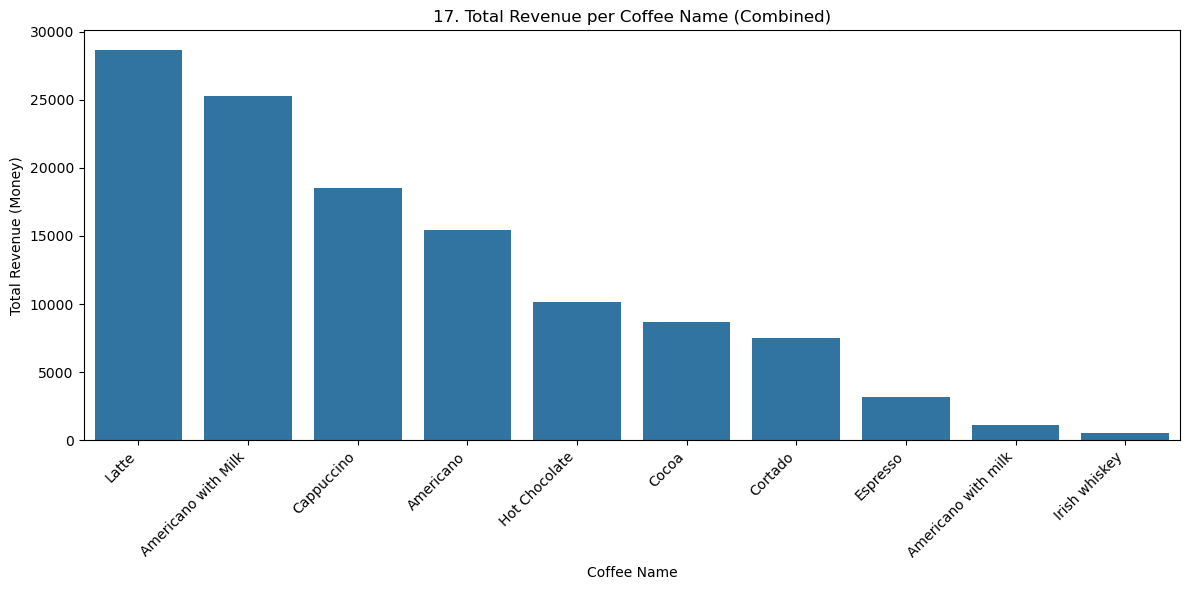

In [13]:
# 17. Plot a bar chart of total revenue per coffee_name using Seaborn.
q17_data = df_combined.groupby('coffee_name')['money'].sum().reset_index()
q17_data = q17_data.sort_values(by='money', ascending=False).nlargest(10, 'money') # Plotting top 10 for clarity
plt.figure(figsize=(12, 6))
sns.barplot(x='coffee_name', y='money', data=q17_data)
plt.title('17. Total Revenue per Coffee Name (Combined)')
plt.xlabel('Coffee Name')
plt.ylabel('Total Revenue (Money)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


13. Total Revenue per Date (First 5 Days):
     date_only  total_revenue
0  2024-03-01          396.3
1  2024-03-02          228.1
2  2024-03-03          349.1
3  2024-03-04          135.2
4  2024-03-05          338.5


18. Line chart saved as 'total_daily_sales_line_chart.png'


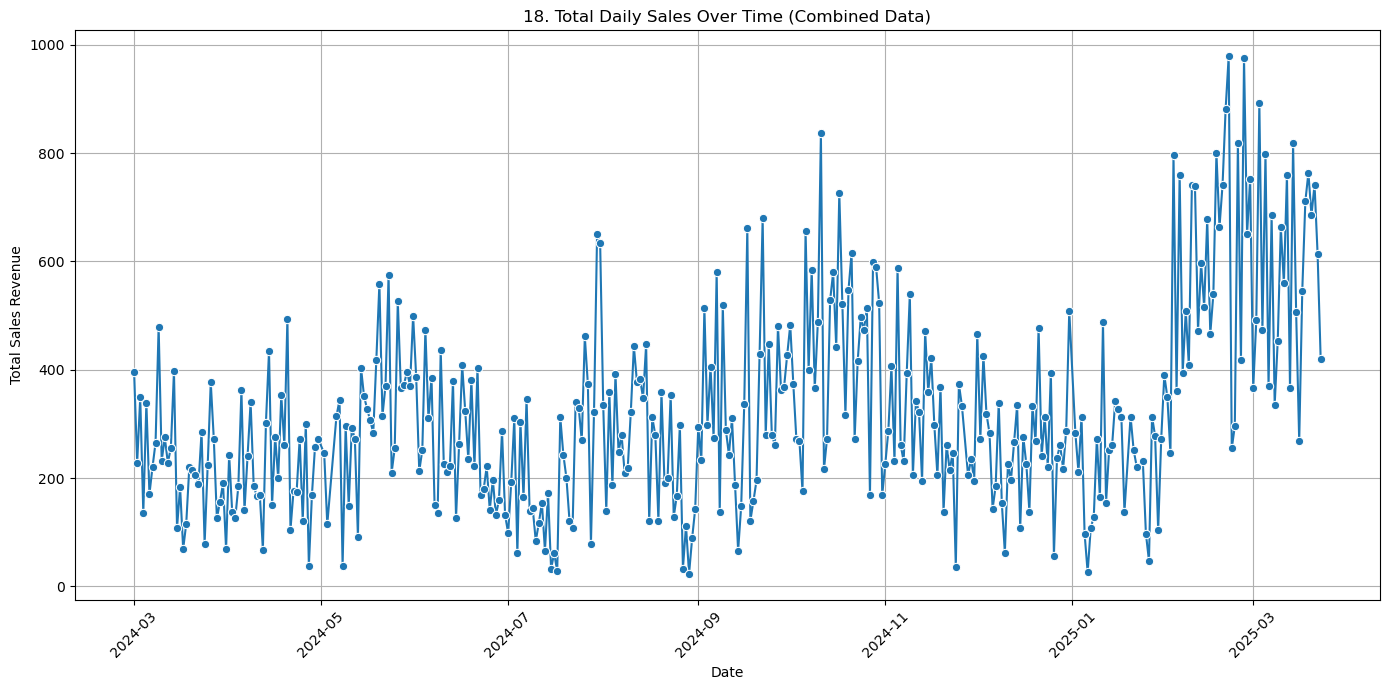

In [15]:

# 13. Combine both datasets and find the total revenue per date.
# We create the 'daily_revenue' DataFrame, explicitly renaming the sum column to 'total_revenue'.
daily_revenue = df_combined.groupby('date_only')['money'].sum().reset_index(name='total_revenue')

print("13. Total Revenue per Date (First 5 Days):\n", daily_revenue.head())
print("\n")

# 18. Plot a line chart showing total daily sales from combined dataset.
# The 'total_revenue' column is now correctly referenced in the lineplot.
plt.figure(figsize=(14, 7))
sns.lineplot(x='date_only', y='total_revenue', data=daily_revenue, marker='o')
plt.title('18. Total Daily Sales Over Time (Combined Data)')
plt.xlabel('Date')
plt.ylabel('Total Sales Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('total_daily_sales_line_chart.png') # Save the plot

print("18. Line chart saved as 'total_daily_sales_line_chart.png'")